# Breast Cancer (UCI Original) — Shared Loader & Helpers

This section sets up **shared utilities** to reuse across all model scripts:
- Load the **UCI Breast Cancer Wisconsin (Original)** dataset **directly from the source**.
- Clean and prepare the data.
- Provide a **stratified train/test split** (75/25).

## Dataset Source (UCI – Original)

We will use the original dataset hosted by UCI:

- URL: `https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(original)`  
- Direct data file: `breast-cancer-wisconsin.data`

**Columns (per UCI):**
1. `sample_code_number` *(ID — will be dropped)*  
2. `clump_thickness`  
3. `uniformity_cell_size`  
4. `uniformity_cell_shape`  
5. `marginal_adhesion`  
6. `single_epithelial_cell_size`  
7. `bare_nuclei` *(contains missing values encoded as '?')*  
8. `bland_chromatin`  
9. `normal_nucleoli`  
10. `mitoses`  
11. `class` *(2 = benign, 4 = malignant)*

**Target mapping for classifiers:**  
- `2 → 0` (benign)  
- `4 → 1` (malignant)


## Preprocessing Plan

1. **Load** the raw CSV directly from the UCI URL (no local file).  
2. **Handle missing values**: Replace `'?'` with `NaN` and drop rows with missing values (only affects `bare_nuclei`).  
3. **Drop ID**: Remove `sample_code_number`.  
4. **Map labels**: `class` values `2→0` (benign) and `4→1` (malignant).  
5. **Return features/labels** as `X, y`.  
6. **Split** with `train_test_split` using `test_size=0.25`, `random_state=42`, and `stratify=y`.


In [2]:
# Imports & constants
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

UCI_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"

COLS = [
    "sample_code_number",            # ID (drop)
    "clump_thickness",
    "uniformity_cell_size",
    "uniformity_cell_shape",
    "marginal_adhesion",
    "single_epithelial_cell_size",
    "bare_nuclei",
    "bland_chromatin",
    "normal_nucleoli",
    "mitoses",
    "class"                          # 2=benign, 4=malignant
]


## `load_clean_data()`

- Reads from the UCI URL.  
- Replaces `'?'` with `NaN` (in `bare_nuclei`).  
- Drops rows with missing values.  
- Drops the ID column.  
- Maps `class` from `{2:0, 4:1}`.  
- Returns `X, y`.


In [3]:
def load_clean_data():
    # Read directly from UCI (no local CSV)
    df = pd.read_csv(UCI_URL, header=None, names=COLS)
    # Handle missing values marked as "?"
    df = df.replace("?", pd.NA)
    df["bare_nuclei"] = pd.to_numeric(df["bare_nuclei"], errors="coerce")
    df = df.dropna().copy()

    # Drop ID column
    df = df.drop(columns=["sample_code_number"])

    # Map class: 2 -> 0 (benign), 4 -> 1 (malignant)
    df["class"] = df["class"].map({2: 0, 4: 1})

    X = df.drop(columns=["class"])
    y = df["class"].astype(int)
    return X, y


## `get_data_splits(test_size=0.25, random_state=42)`

- Returns a stratified 75/25 train/test split.  
- Keeps results reproducible via `random_state`.


In [4]:
def get_data_splits(test_size=0.25, random_state=42):
    X, y = load_clean_data()
    return train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )


## `evaluate_and_log(model_name, y_true, y_pred, results_dir="results")`

Logs metrics for compiling the **Word table later**:

- Appends one row per model to `results/metrics.csv` with: `model`, `accuracy`.  
- Appends one row per model to `results/confusion_matrices.csv` with: `model`, `tn`, `fp`, `fn`, `tp`.  
- Prints summary to the console.


In [5]:
def evaluate_and_log(model_name, y_true, y_pred, results_dir="results"):
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)  # [[TN, FP], [FN, TP]]

    os.makedirs(results_dir, exist_ok=True)

    # Append metrics row
    metrics_path = os.path.join(results_dir, "metrics.csv")
    mrow = pd.DataFrame([{
        "model": model_name,
        "accuracy": acc
    }])
    if os.path.exists(metrics_path):
        mrow.to_csv(metrics_path, mode="a", header=False, index=False)
    else:
        mrow.to_csv(metrics_path, index=False)

    # Append confusion matrix row as a flat record
    cm_path = os.path.join(results_dir, "confusion_matrices.csv")
    cmrow = pd.DataFrame([{
        "model": model_name,
        "tn": int(cm[0,0]),
        "fp": int(cm[0,1]),
        "fn": int(cm[1,0]),
        "tp": int(cm[1,1]),
    }])
    if os.path.exists(cm_path):
        cmrow.to_csv(cm_path, mode="a", header=False, index=False)
    else:
        cmrow.to_csv(cm_path, index=False)

    print(f"{model_name} | Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(cm)


## Preview the Cleaned Dataset

Let’s load the data and inspect the first few rows to confirm:
- Missing values are gone  
- `sample_code_number` is dropped  
- `class` is mapped to `0` (benign) and `1` (malignant)


In [6]:
# Preview cleaned data
X, y = load_clean_data()
print("Features shape:", X.shape)
print("Labels distribution:\n", y.value_counts())

# Show first 5 rows
pd.concat([X, y], axis=1).head()


Features shape: (683, 9)
Labels distribution:
 class
0    444
1    239
Name: count, dtype: int64


,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
0,5,1,1,1,2,1.0,3,1,1,0
1,5,4,4,5,7,10.0,3,2,1,0
2,3,1,1,1,2,2.0,3,1,1,0
3,6,8,8,1,3,4.0,3,7,1,0
4,4,1,1,3,2,1.0,3,1,1,0


## Sanity check: class balance after split
Confirm stratification worked and the test size is 25%.


In [7]:
X_train, X_test, y_train, y_test = get_data_splits()
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train label distribution:\n", y_train.value_counts(normalize=True).round(3))
print("Test  label distribution:\n", y_test.value_counts(normalize=True).round(3))


Train shape: (512, 9)  Test shape: (171, 9)
Train label distribution:
 class
0    0.65
1    0.35
Name: proportion, dtype: float64
Test  label distribution:
 class
0    0.649
1    0.351
Name: proportion, dtype: float64


## Model 8 — XGBoost

Gradient-boosted trees (XGBoost) add trees sequentially to correct prior errors, often yielding strong accuracy and recall with well‑shaped ROC/PR curves. We’ll keep settings consistent with prior models.


In [11]:
# XGBoost: train, predict, log
from xgboost import XGBClassifier

# 1) data
X_train, X_test, y_train, y_test = get_data_splits()

# 2) model (keep it small/consistent with prior runs)
xgb_clf = XGBClassifier(
    n_estimators=10,
    max_depth=3,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42,
    eval_metric="logloss"  # keep this
)

# 3) fit & predict
xgb_clf.fit(X_train, y_train)
y_pred_xgb  = xgb_clf.predict(X_test)

# 4) log
evaluate_and_log("XGBoost (n=10)", y_test, y_pred_xgb)


XGBoost (n=10) | Accuracy: 0.9649
Confusion Matrix:
[[106   5]
 [  1  59]]


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve

# probabilities
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

# confusion & metrics
cm = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm.ravel()

acc  = accuracy_score(y_test, y_pred_xgb)
prec = precision_score(y_test, y_pred_xgb, zero_division=0)
rec  = recall_score(y_test, y_pred_xgb, zero_division=0)
spec = tn / (tn + fp) if (tn + fp) else np.nan
f1   = f1_score(y_test, y_pred_xgb, zero_division=0)

# curves
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
roc_auc     = roc_auc_score(y_test, y_proba_xgb)

prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba_xgb)
ap          = average_precision_score(y_test, y_proba_xgb)

# calibration
prob_true, prob_pred = calibration_curve(y_test, y_proba_xgb, n_bins=10, strategy="uniform")


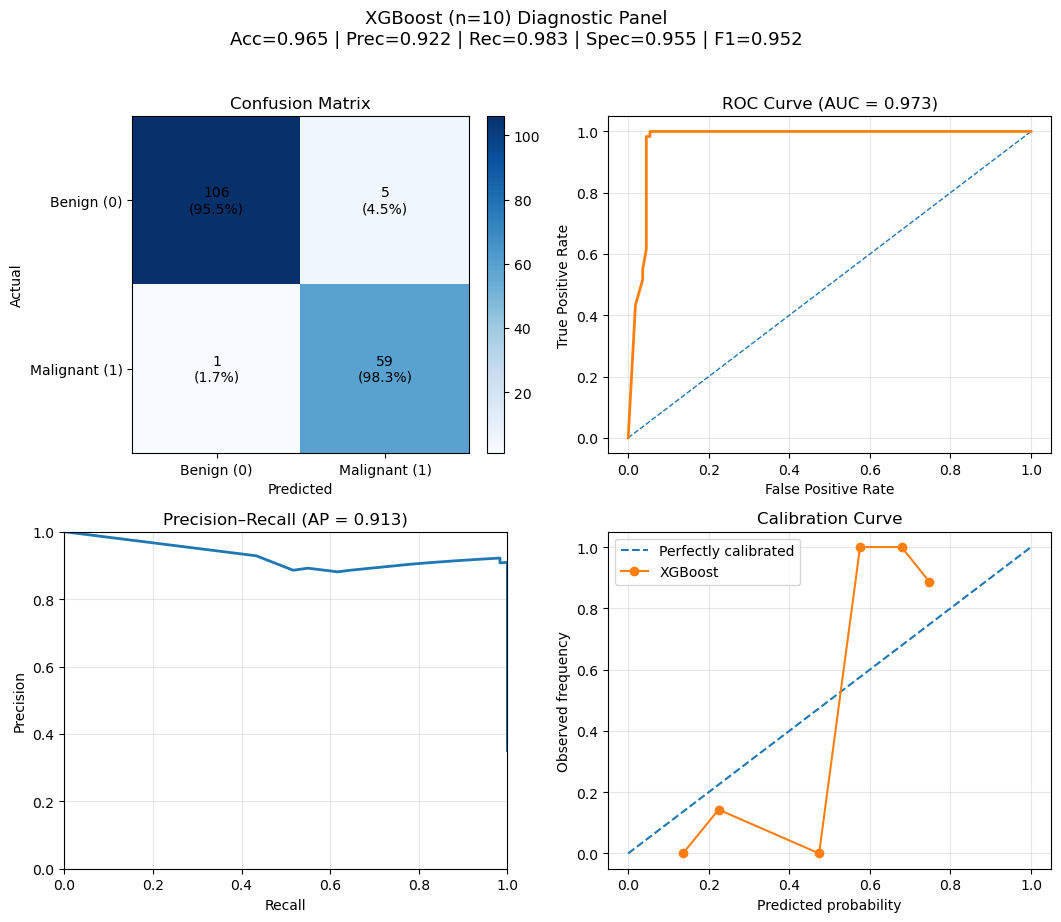

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
(ax_cm, ax_roc), (ax_pr, ax_cal) = axes

# Confusion matrix
im = ax_cm.imshow(cm, cmap="Blues")
ax_cm.set_title("Confusion Matrix")
ax_cm.set_xlabel("Predicted"); ax_cm.set_ylabel("Actual")
ax_cm.set_xticks([0,1]); ax_cm.set_xticklabels(["Benign (0)","Malignant (1)"])
ax_cm.set_yticks([0,1]); ax_cm.set_yticklabels(["Benign (0)","Malignant (1)"])
for (i, j), val in np.ndenumerate(cm):
    row_total = cm[i].sum()
    pct = (val / row_total * 100) if row_total else 0
    ax_cm.text(j, i, f"{val}\n({pct:.1f}%)", ha="center", va="center", fontsize=10)
fig.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)

# ROC
ax_roc.plot([0,1],[0,1], linestyle="--", linewidth=1)
ax_roc.plot(fpr, tpr, linewidth=2)
ax_roc.set_title(f"ROC Curve (AUC = {roc_auc:.3f})")
ax_roc.set_xlabel("False Positive Rate"); ax_roc.set_ylabel("True Positive Rate")
ax_roc.grid(alpha=0.3)

# Precision–Recall
ax_pr.plot(rec_curve, prec_curve, linewidth=2)
ax_pr.set_title(f"Precision–Recall (AP = {ap:.3f})")
ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")
ax_pr.set_xlim(0,1); ax_pr.set_ylim(0,1)
ax_pr.grid(alpha=0.3)

# Calibration
ax_cal.plot([0,1],[0,1], linestyle="--", label="Perfectly calibrated")
ax_cal.plot(prob_pred, prob_true, marker="o", linewidth=1.5, label="XGBoost")
ax_cal.set_title("Calibration Curve")
ax_cal.set_xlabel("Predicted probability"); ax_cal.set_ylabel("Observed frequency")
ax_cal.legend(); ax_cal.grid(alpha=0.3)

fig.suptitle(
    f"XGBoost (n=10) Diagnostic Panel\n"
    f"Acc={acc:.3f} | Prec={prec:.3f} | Rec={rec:.3f} | Spec={spec:.3f} | F1={f1:.3f}",
    y=1.02, fontsize=13
)
plt.tight_layout()
plt.show()


### XGBoost (n=10) — Model Performance Summary

**Key Metrics:**  
- **Accuracy:** 96.5% — Among the top-performing models in this set.  
- **Precision:** 92.2% — High likelihood that malignant predictions are correct.  
- **Recall (Sensitivity):** 98.3% — Nearly all malignant cases correctly identified.  
- **Specificity:** 95.5% — Strong benign classification.  
- **F1 Score:** 95.2% — Well-balanced between precision and recall.  
- **ROC AUC:** 0.973 — Excellent class separability.  
- **PR AUC:** 0.913 — Strong precision–recall trade-off across thresholds.  

**Confusion Matrix:**  
- **True Negatives (TN):** 106  
- **False Positives (FP):** 5  
- **False Negatives (FN):** 1  
- **True Positives (TP):** 59  

**Interpretation:**  
The XGBoost model achieved excellent overall performance, with recall (98.3%) ensuring nearly all malignant cases were correctly detected and precision (92.2%) keeping false positives low. Its ROC AUC of 0.973 and PR AUC of 0.913 demonstrate strong discriminatory ability and stable performance across thresholds. The calibration curve shows some irregularity at lower probability ranges but tracks closely with perfect calibration at higher probabilities. This model combines high sensitivity with balanced precision, making it a dependable choice for minimizing missed malignant diagnoses while keeping false alarms manageable.
